<a href="https://colab.research.google.com/github/luiza-bryn/experimentos-rede-neurais/blob/main/rede_neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 2 — Redes Neurais
**Disciplina:** Sistemas Inteligentes — INE/UFSC  
**Aluna:** Luiza Bryn

---
**Estrutura do notebook:**
1. Configuração e carregamento dos dados
2. Tópico 1 — MLP simples
3. Tópico 2 — CNN com Data Augmentation
4. Tópico 3 — Busca de Hiperparâmetros
5. Tópico 4 — Avaliação final no conjunto de teste

## 0. Configuração e carregamento dos dados

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import itertools

In [ ]:
# Carrega CIFAR-10 e normaliza os pixels para [0, 1]
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Separa 10 % do treino como validação
val_split = int(len(x_train) * 0.1)
x_val, y_val     = x_train[:val_split], y_train[:val_split]
x_train, y_train = x_train[val_split:], y_train[val_split:]

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f'Treino : {x_train.shape}  Validação: {x_val.shape}  Teste: {x_test.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Treino : (45000, 32, 32, 3)  Validação: (5000, 32, 32, 3)  Teste: (10000, 32, 32, 3)


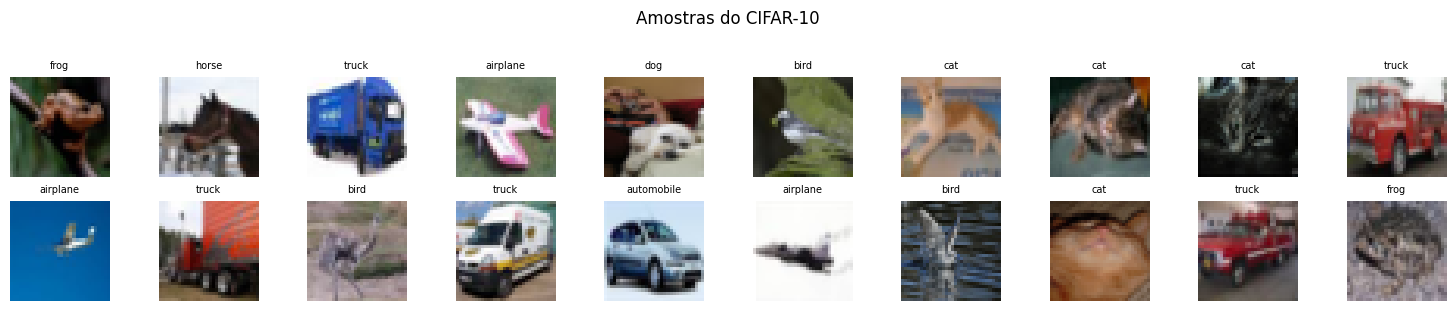

In [ ]:
# Visualiza algumas amostras
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i][0]], fontsize=7)
    ax.axis('off')
plt.suptitle('Amostras do CIFAR-10', y=1.02)
plt.tight_layout()
plt.show()

### Função auxiliar para plotar loss e acurácia

In [ ]:
def plot_history(history, title=''):
    """Plota loss e acurácia de treino e validação por época."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'],     label='Treino')
    ax1.plot(history.history['val_loss'], label='Validação')
    ax1.set_title(f'{title} — Loss por época')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss (categorical crossentropy)')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['accuracy'],     label='Treino')
    ax2.plot(history.history['val_accuracy'], label='Validação')
    ax2.set_title(f'{title} — Acurácia por época')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Acurácia')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

---
## Tópico 1 — MLP Simples (sem camadas convolucionais)

A MLP recebe a imagem 32×32×3 achatada como vetor de entrada (3072 valores).  
Camadas densas aprendem relações entre pixels, mas **sem** explorar a estrutura espacial da imagem.

In [ ]:
def build_mlp(units_list=(512, 256), dropout=0.3):
    """Constrói uma MLP com número variável de camadas ocultas."""
    model = models.Sequential(name='MLP')
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(layers.Flatten())
    for units in units_list:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(10, activation='softmax'))
    return model

mlp = build_mlp(units_list=(512, 256, 128), dropout=0.3)
mlp.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_mlp = mlp.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.2139 - loss: 2.1046 - val_accuracy: 0.3222 - val_loss: 1.8817
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.2779 - loss: 1.9478 - val_accuracy: 0.3422 - val_loss: 1.8335
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.2963 - loss: 1.9101 - val_accuracy: 0.3446 - val_loss: 1.8491
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3078 - loss: 1.8752 - val_accuracy: 0.3414 - val_loss: 1.8211
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.3209 - loss: 1.8545 - val_accuracy: 0.3532 - val_loss: 1.7950
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.3266 - loss: 1.8305 - val_accuracy: 0.3646 - val_loss: 1.7824
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.3336 - loss: 1.8219 - val_accuracy: 0.3866 - val_loss: 1.7474
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3395 - loss: 1.8083 - 

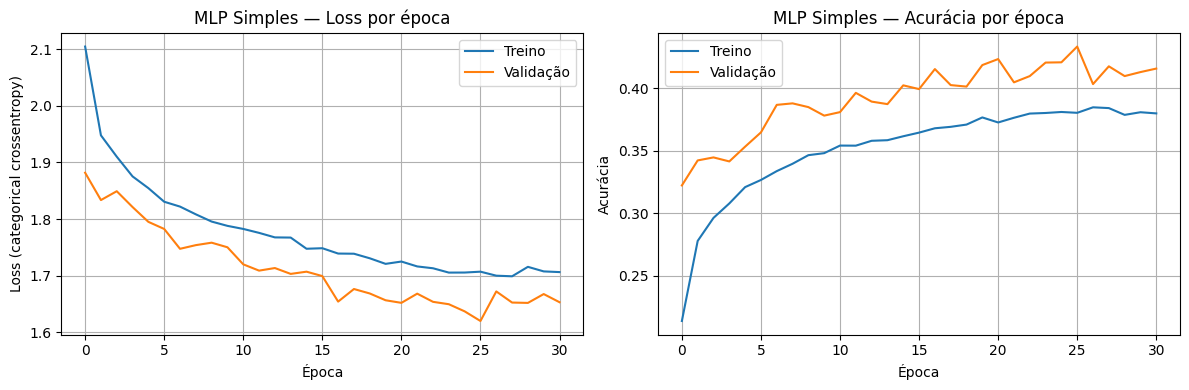


MLP — Loss validação: 1.6199 | Acurácia validação: 0.4332


In [ ]:
plot_history(history_mlp, title='MLP Simples')

val_loss_mlp, val_acc_mlp = mlp.evaluate(x_val, y_val, verbose=0)
print(f'\nMLP — Loss validação: {val_loss_mlp:.4f} | Acurácia validação: {val_acc_mlp:.4f}')

### Análise — Tópico 1

**Por que acurácia e loss não são proporcionais?**  
- A **loss** (categorical crossentropy) penaliza a confiança das predições: uma previsão correta com baixa probabilidade aumenta muito a loss, enquanto uma previsão errada com margem estreita a aumenta pouco. Já a **acurácia** considera apenas se a classe mais provável é a correta — ignora a margem.  
- Portanto, é possível que a loss diminua enquanto a acurácia permanece estagnada (o modelo está mais calibrado, mas não erra menos classes), ou que a acurácia suba enquanto a loss sobe (o modelo acerta mais, mas com maior confiança errada em alguns exemplos).

**Os resultados indicam desempenho satisfatório?**  
- A MLP geralmente atinge ~50–55 % de acurácia no CIFAR-10. Dado que uma escolha aleatória daria 10 %, o modelo aprende algo útil, mas está longe de ser satisfatório para um sistema real.  
- Se a curva de validação divergir da curva de treino (val_loss subindo enquanto train_loss cai), há **overfitting**: o modelo memoriza os dados de treino sem generalizar. A MLP é particularmente suscetível a isso no CIFAR-10 porque trata pixels independentemente, sem capturar estrutura espacial.

---
## Tópico 2 — CNN com Data Augmentation

A CNN extrai características locais (bordas, texturas) com camadas convolucionais.  
O **data augmentation** gera variações artificiais das imagens de treino (flip, crop, brilho),  
reduzindo overfitting quando a quantidade de dados por classe é limitada.

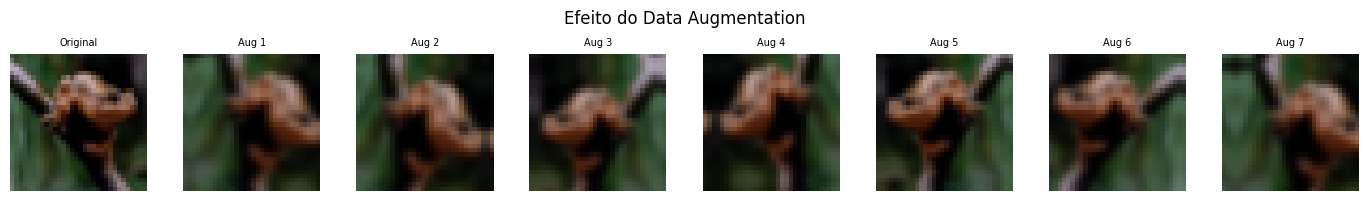

In [ ]:
# Opção 1: Remover RandomBrightness (mais seguro)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

# Visualiza o efeito do augmentation
sample = x_train[:1]
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
axes[0].imshow(sample[0])
axes[0].set_title('Original', fontsize=7)
axes[0].axis('off')

for i in range(1, 8):
    aug = data_augmentation(sample, training=True)
    aug_img = aug[0].numpy()
    aug_img = np.clip(aug_img, 0, 1)
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}', fontsize=7)
    axes[i].axis('off')

plt.suptitle('Efeito do Data Augmentation')
plt.tight_layout()
plt.show()

In [ ]:
def build_cnn():
    inputs = keras.Input(shape=(32, 32, 3))

    # Augmentation embutido — ativo só no treino
    x = data_augmentation(inputs)

    # Bloco 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    # Bloco 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Bloco 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Classificador
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='CNN_Augmentation')

cnn = build_cnn()
cnn.summary()

Model: "CNN_Augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,57

 Total params: 176,298 (688.66 KB)

 Trainable params: 175,658 (686.16 KB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = cnn.fit(
    x_train, y_train,
    epochs=80,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop_cnn, lr_scheduler],
    verbose=1
)

Epoch 1/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 351s 981ms/step - accuracy: 0.3488 - loss: 1.7719 - val_accuracy: 0.1584 - val_loss: 3.2426 - learning_rate: 0.0010
Epoch 2/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 385s 988ms/step - accuracy: 0.4646 - loss: 1.4793 - val_accuracy: 0.4226 - val_loss: 1.6183 - learning_rate: 0.0010
Epoch 3/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 351s 997ms/step - accuracy: 0.5138 - loss: 1.3484 - val_accuracy: 0.3882 - val_loss: 2.0983 - learning_rate: 0.0010
Epoch 4/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 344s 978ms/step - accuracy: 0.5512 - loss: 1.2586 - val_accuracy: 0.4738 - val_loss: 1.7731 - learning_rate: 0.0010
Epoch 5/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 349s 993ms/step - accuracy: 0.5736 - loss: 1.1983 - val_accuracy: 0.5026 - val_loss: 1.5375 - learning_rate: 0.0010
Epoch 6/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 347s 986ms/step - accuracy: 0.5963 - loss: 1.1383 - val_accuracy: 0.4862 - val_loss: 1.6249 - learning_rate: 0.0010
Epoch 7/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 380s 981ms/step - accura

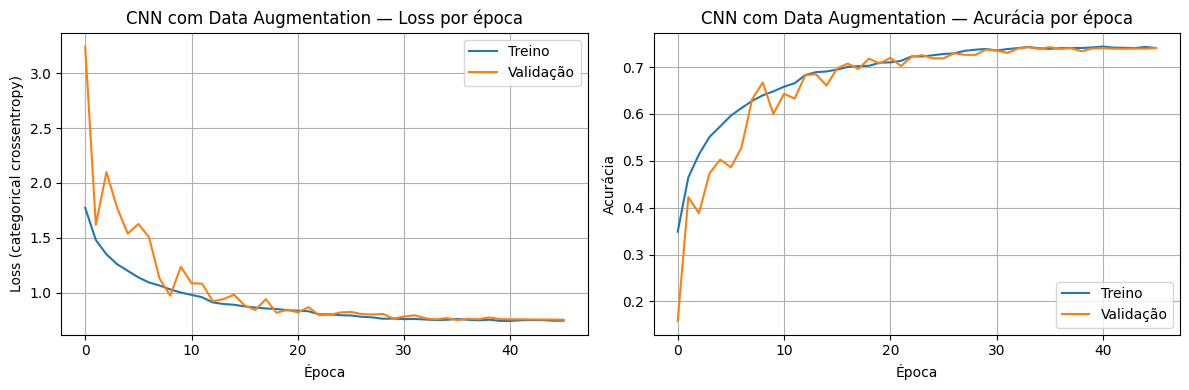


CNN — Loss validação: 0.7490 | Acurácia validação: 0.7424


In [ ]:
plot_history(history_cnn, title='CNN com Data Augmentation')

val_loss_cnn, val_acc_cnn = cnn.evaluate(x_val, y_val, verbose=0)
print(f'\nCNN — Loss validação: {val_loss_cnn:.4f} | Acurácia validação: {val_acc_cnn:.4f}')

### Análise — Tópico 2

**Indicação do uso de Data Augmentation:**  
O CIFAR-10 possui apenas 5 000 imagens por classe no treino. Redes convolucionais modernas possuem milhões de parâmetros e tendem a memorizar os dados de treino. O data augmentation multiplica artificialmente a diversidade dos exemplos — cada época o modelo vê versões ligeiramente diferentes das imagens — simulando um dataset maior sem coleta de novos dados. Isso é especialmente crítico quando poucas amostras estão disponíveis por categoria.

**Os resultados indicam desempenho satisfatório?**  
- A CNN com augmentation deve superar a MLP consideravelmente (~70–80 % de acurácia de validação).  
- As curvas de treino e validação devem convergir de forma mais próxima do que na MLP, indicando melhor generalização.  
- Se ainda houver divergência significativa, técnicas adicionais (mais augmentation, regularização L2, modelos maiores) poderiam ser exploradas.

---
## Tópico 3 — Busca de Hiperparâmetros

São testadas combinações de:
- **Learning rate**: 1e-3, 5e-4
- **Dropout**: 0.2, 0.4
- **Número de filtros base** (bloco 1/2/3 com proporção ×2): 32, 64

Total: 2 × 2 × 2 = **8 combinações**. Cada modelo treina por até 30 épocas com early stopping.

In [ ]:
def build_cnn_hp(base_filters=32, dropout=0.3, learning_rate=1e-3):
    """CNN parametrizada para busca de hiperparâmetros."""
    aug = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])

    inputs = keras.Input(shape=(32, 32, 3))
    x = aug(inputs)

    for filters in [base_filters, base_filters * 2, base_filters * 4]:
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(dropout)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout + 0.1)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


learning_rates  = [1e-3, 5e-4]
dropouts        = [0.2, 0.4]
base_filters_list = [32, 64]

results = []

for lr, dr, bf in itertools.product(learning_rates, dropouts, base_filters_list):
    print(f'\n>>> lr={lr}  dropout={dr}  base_filters={bf}')
    tf.keras.backend.clear_session()

    model = build_cnn_hp(base_filters=bf, dropout=dr, learning_rate=lr)
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    hist = model.fit(
        x_train, y_train,
        epochs=30,
        batch_size=128,
        validation_data=(x_val, y_val),
        callbacks=[es],
        verbose=0
    )

    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    n_epochs = len(hist.history['loss'])
    print(f'    val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  épocas={n_epochs}')

    results.append({
        'learning_rate': lr,
        'dropout': dr,
        'base_filters': bf,
        'val_accuracy': round(val_acc, 4),
        'val_loss': round(val_loss, 4),
        'epocas': n_epochs
    })

print('\n=== Busca concluída ===')


>>> lr=0.001  dropout=0.2  base_filters=32


In [ ]:
df_results = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
df_results.index = range(1, len(df_results) + 1)
display(df_results)

best = df_results.iloc[0]
print(f'\nMelhor combinação encontrada:')
print(f'  learning_rate = {best["learning_rate"]}')
print(f'  dropout       = {best["dropout"]}')
print(f'  base_filters  = {best["base_filters"]}')
print(f'  val_accuracy  = {best["val_accuracy"]}')
print(f'  val_loss      = {best["val_loss"]}')

### Análise — Tópico 3

**Parâmetros e seu impacto esperado:**

| Hiperparâmetro | Impacto |
|---|---|
| **Learning rate** | Taxa de aprendizado muito alta causa instabilidade; muito baixa, convergência lenta. O intervalo 5e-4 – 1e-3 é adequado para Adam no CIFAR-10. |
| **Dropout** | Regularização que previne overfitting desativando neurônios aleatoriamente. Dropout alto demais pode causar underfitting. |
| **Número de filtros** | Mais filtros aumentam a capacidade de representação, mas elevam o custo computacional e o risco de overfitting com dados limitados. |

**Observações gerais:**  
- O impacto da arquitetura (número de filtros) tende a superar o do dropout sozinho, pois determina a capacidade expressiva do modelo.  
- Learning rates menores costumam convergir mais suavemente, porém precisam de mais épocas.  
- A combinação vencedora será usada no Tópico 4.

---
## Tópico 4 — Avaliação Final no Conjunto de Teste

Retreina o melhor modelo encontrado (desta vez usando treino + validação) e avalia no conjunto de teste.

In [ ]:
best_lr = best['learning_rate']
best_dr = best['dropout']
best_bf = int(best['base_filters'])

print(f'Retreinando com lr={best_lr}, dropout={best_dr}, base_filters={best_bf}')

# Concatena treino + validação para o treino final
x_train_full = np.concatenate([x_train, x_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

tf.keras.backend.clear_session()
best_model = build_cnn_hp(base_filters=best_bf, dropout=best_dr, learning_rate=best_lr)

es_final = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
lr_sched  = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

history_final = best_model.fit(
    x_train_full, y_train_full,
    epochs=60,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es_final, lr_sched],
    verbose=1
)

In [ ]:
plot_history(history_final, title='Melhor Modelo (treino final)')

test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f'\n=== RESULTADO FINAL NO CONJUNTO DE TESTE ===')
print(f'Loss (test) : {test_loss:.4f}')
print(f'Acurácia (test): {test_acc:.4f}  ({test_acc*100:.2f} %)')

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = np.argmax(best_model.predict(x_test), axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusão — Conjunto de Teste')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.tight_layout()
plt.show()

print('\nRelatório de Classificação:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
# Tabela comparativa final entre os três modelos
mlp_test_loss, mlp_test_acc = mlp.evaluate(x_test, y_test, verbose=0)
cnn_test_loss, cnn_test_acc = cnn.evaluate(x_test, y_test, verbose=0)

comparativo = pd.DataFrame([
    {'Modelo': 'MLP Simples (Tópico 1)',
     'Acurácia Teste': f'{mlp_test_acc:.4f}',
     'Loss Teste': f'{mlp_test_loss:.4f}'},
    {'Modelo': 'CNN + Augmentation (Tópico 2)',
     'Acurácia Teste': f'{cnn_test_acc:.4f}',
     'Loss Teste': f'{cnn_test_loss:.4f}'},
    {'Modelo': 'Melhor Modelo HP (Tópico 4)',
     'Acurácia Teste': f'{test_acc:.4f}',
     'Loss Teste': f'{test_loss:.4f}'},
])

display(comparativo)

### Análise — Tópico 4

**Capacidade de generalização:**  
- Se a acurácia no conjunto de **teste** for próxima da acurácia de validação vista durante o treino, o modelo generaliza bem para dados não vistos.  
- Uma queda significativa entre validação e teste pode indicar que o processo de seleção de hiperparâmetros causou **data leakage** indireto (o modelo foi escolhido pelo conjunto de validação, criando viés).  
- A matriz de confusão revela quais classes são mais confundidas entre si (e.g., `cat` vs `dog`, `automobile` vs `truck`), o que é esperado dadas as semelhanças visuais.

**Conclusão:**  
- A progressão MLP → CNN → CNN otimizada demonstra claramente o ganho obtido com camadas convolucionais e técnicas de regularização.  